In [28]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

In [29]:
from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass
import pandas as pd

@dataclass
class Grouped:
    name: str
    fraction: float
    replicas_keys: list[str]

In [30]:
import pathlib
FIGDIR = pathlib.Path("figs_tesis")
FIGDIR.mkdir(exist_ok=True)

In [31]:
save_path = "/Users/niaggar/Results"
fraction_list = np.linspace(0.0, 1.0, 11)
N_MEDIUM = 1.33
WAVELENGTH = 0.514 
k = 2 * np.pi * N_MEDIUM / WAVELENGTH
N_REPLICAS = 5


# Linear Polarization study of RGD particles

In [32]:
folder_lineal = "study_mixture_layer__PLIN__beam2500"
sweep_data_lineal = load_sweep(folder_lineal, base_path=Path(save_path))

data_keys = list(sweep_data_lineal.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")


grouped_data_lineal = []
for frac in fraction_list:
    replicas_keys = [key for key in data_keys if f"fraction_{frac:.2f}" in key]
    grouped = Grouped(fraction=frac, replicas_keys=replicas_keys, name=rf"F={frac:.2f}")
    grouped_data_lineal.append(grouped)

print(grouped_data_lineal)


Loaded 60 datasets: ['0017_fraction_0.30__rep2', '0058_matched_ref_r0.035__rep3', '0023_fraction_0.40__rep3', '0009_fraction_0.10__rep4', '0008_fraction_0.10__rep3', '0022_fraction_0.40__rep2', '0049_fraction_0.90__rep4', '0026_fraction_0.50__rep1', '0025_fraction_0.50__rep0', '0011_fraction_0.20__rep1', '0048_fraction_0.90__rep3', '0010_fraction_0.20__rep0', '0024_fraction_0.40__rep4', '0051_fraction_1.00__rep1', '0036_fraction_0.70__rep1', '0035_fraction_0.70__rep0', '0001_fraction_0.00__rep1', '0000_fraction_0.00__rep0', '0047_fraction_0.90__rep2', '0034_fraction_0.60__rep4', '0050_fraction_1.00__rep0', '0056_matched_ref_r0.035__rep1', '0040_fraction_0.80__rep0', '0007_fraction_0.10__rep2', '0033_fraction_0.60__rep3', '0059_matched_ref_r0.035__rep4', '0019_fraction_0.30__rep4', '0041_fraction_0.80__rep1', '0018_fraction_0.30__rep3', '0032_fraction_0.60__rep2', '0016_fraction_0.30__rep1', '0021_fraction_0.40__rep1', '0015_fraction_0.30__rep0', '0020_fraction_0.40__rep0', '0014_fracti

In [33]:
eps = 1e-30

def load_stitched(channel, k, lstar, th1, g1, th2, g2, key):
    theta_1 = th1[-1]                       # fin de la ventana fina
    lo = 0.9 * theta_1                       # inicio real de det_2 (solape)

    # --- chequeo de stitching: interpola det_1 sobre los bins de solape de det_2
    ov = (th2 >= lo) & (th2 <= theta_1)
    if ov.any():
        g1_on2 = np.interp(th2[ov], th1, g1)
        resid = np.abs(g2[ov] - g1_on2)
        if np.max(resid) > 0.05:            # umbral: 5% del enhancement
            print(f"[stitch WARN] {key} ch={channel}: max solape "
                  f"{np.max(resid):.3f} -- revisar normalizacion angulo solido")

    # une: det_1 completo + det_2 estrictamente por encima de theta_1
    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])
    q = k * lstar * theta
    return theta, q, g

def tail_baseline(q, y, q_min=25.0, n_min=5, frac=0.85):
    """Fondo en la cola, inmune a ventanas vacías.
    Usa q>q_min si hay puntos suficientes; si no, cae al tramo alto
    del q realmente disponible para ese radio."""
    q = np.asarray(q); y = np.asarray(y)
    m = q > q_min
    if np.count_nonzero(m) >= n_min:
        return np.median(y[m])
    q_cut = frac * np.nanmax(q)          # último ~15 % del q disponible
    m = q >= q_cut
    if np.count_nonzero(m) < n_min:
        idx = np.argsort(q)[-n_min:]     # los n_min puntos de mayor q
        return np.median(y[idx])
    return np.median(y[m])

def load_mean_enhancement(grouped_rad, basis, reduce, time_index, chanel, k):
    I_incoherent_total_1 = None
    I_incoherent_total_2 = None
    I_coherent_total_1 = None
    I_coherent_total_2 = None
    for key in grouped_rad.replicas_keys:
        sweep = sweep_data_lineal[key]

        p1 = cbs_profiles(sweep.processed_cbs("farfield_cbs_1"), basis=basis, time_index=time_index, reduce=reduce)
        p2 = cbs_profiles(sweep.processed_cbs("farfield_cbs_2"), basis=basis, time_index=time_index, reduce=reduce)

        if I_incoherent_total_1 is None:
            I_incoherent_total_1 = np.zeros_like(p1.incoherent[chanel])
            I_incoherent_total_2 = np.zeros_like(p2.incoherent[chanel])
            I_coherent_total_1 = np.zeros_like(p1.coherent[chanel])
            I_coherent_total_2 = np.zeros_like(p2.coherent[chanel])

        I_incoherent_total_1 = I_incoherent_total_1 + p1.incoherent[chanel]
        I_incoherent_total_2 = I_incoherent_total_2 + p2.incoherent[chanel]
        I_coherent_total_1 = I_coherent_total_1 + p1.coherent[chanel]
        I_coherent_total_2 = I_coherent_total_2 + p2.coherent[chanel]

    enhancement_1 = (I_coherent_total_1 + eps) / (I_incoherent_total_1 + eps)
    enhancement_2 = (I_coherent_total_2 + eps) / (I_incoherent_total_2 + eps)
    sweep0 = sweep_data_lineal[grouped_rad.replicas_keys[0]]
    p0_1 = cbs_profiles(sweep0.processed_cbs("farfield_cbs_1"), basis=basis, time_index=time_index, reduce=reduce)
    p0_2 = cbs_profiles(sweep0.processed_cbs("farfield_cbs_2"), basis=basis, time_index=time_index, reduce=reduce)
    theta_1 = p0_1.theta
    theta_2 = p0_2.theta

    lstar0 = sweep_data_lineal[grouped_rad.replicas_keys[0]].params_flat["transport_mean_free_path"]
    theta, q, enhancement = load_stitched(chanel, k, lstar0, theta_1, enhancement_1, theta_2, enhancement_2, grouped_rad.replicas_keys[0])

    return theta, q, enhancement

PHI_DEG = {0: 0, 1: 45, 2: 90}   # indices de set_phi_slices([0, pi/4, pi/2])

def get_profile(grouped_rad, phi_index, channel, time_index=0):
    """Perfil E(q) promediado sobre replicas, con baseline llevada a 1."""
    _, q, E = load_mean_enhancement(grouped_rad, linear, phi_cut(phi_index),
                                    time_index, channel, k)
    base = tail_baseline(q, E, q_min=25.0)
    return q, E - base + 1.0

def peak_height(q, E, n=3):
    """E(0) estimado como mediana de los primeros n bins (robusto al ruido del apice)."""
    return np.median(E[:n])

def fwhm_q(q, E, n=3):
    """Ancho total a mitad de altura en unidades de q, por interpolacion lineal."""
    E0 = peak_height(q, E, n)
    half = 1.0 + 0.5 * (E0 - 1.0)
    below = np.where(E < half)[0]
    if len(below) == 0:
        return np.nan
    i = below[0]                                  # primer bin bajo el semi-maximo
    # interpolacion entre (i-1, i):
    q_half = q[i-1] + (half - E[i-1]) * (q[i] - q[i-1]) / (E[i] - E[i-1])
    return 2.0 * q_half                            # cono simetrico en theta

def profile_one(sweep, key, phi_index, channel, time_index=0, basis=linear):
    """Perfil E(q) de UNA replica, baseline llevada a 1."""
    reducer = phi_cut(phi_index) if basis == linear else azimuthal_average
    sw = sweep[key]
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=basis,
                      time_index=time_index, reduce=reducer)
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=basis,
                      time_index=time_index, reduce=reducer)
    E1 = (p1.coherent[channel] + eps) / (p1.incoherent[channel] + eps)
    E2 = (p2.coherent[channel] + eps) / (p2.incoherent[channel] + eps)
    lst = sw.params_flat["transport_mean_free_path"]
    _, q, E = load_stitched(channel, k, lst, p1.theta, E1, p2.theta, E2, key)
    return q, E - tail_baseline(q, E) + 1.0

def profile_stats(sweep, grouped_rad, phi_index, channel, time_index=0, basis=linear):
    """Media y desviacion estandar (ddof=1) sobre las replicas."""
    curves = []
    for key in grouped_rad.replicas_keys:
        q, E = profile_one(sweep, key, phi_index, channel, time_index=time_index, basis=basis)
        curves.append(E)
    C = np.vstack(curves)
    return q, C.mean(axis=0), C.std(axis=0, ddof=1)

def mirror(q, *ys):
    """Espejo -q..+q para presentacion estilo Iwai (valido: I(th,phi)=I(th,phi+pi))."""
    return (np.r_[-q[::-1], q],) + tuple(np.r_[y[::-1], y] for y in ys)

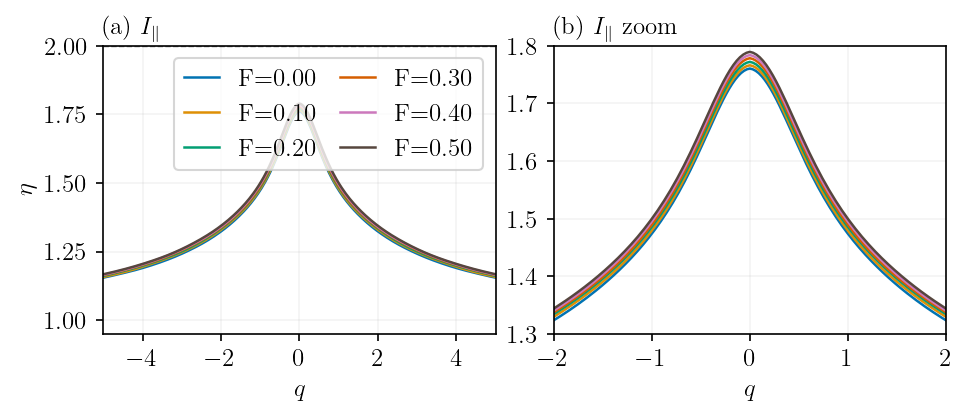

In [34]:
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42*TEXTWIDTH_IN), sharey=False)

for c, g_ in zip(COL, grouped_data_lineal):
    q, m, s = profile_stats(sweep_data_lineal, g_, 0, "co", time_index=0, basis=linear)          # phi = 0 (X-scan)
    qs, ms, ss = mirror(q, m, s)

    ax1.plot(qs, ms, color=c, label=g_.name)
    ax2.plot(qs, ms, color=c, label=g_.name)


for ax, t in ((ax1, "(a) $I_\\parallel$"), (ax2, "(b) $I_\\parallel$ zoom")):
    ax.set_xlim(-5, 5)
    ax.set_ylim(0.95, 2.0)
    ax.set_xlabel(r"$q$")
    ax.grid(alpha=0.15)

ax1.set_ylabel(r"$\eta$")
ax1.axhline(2.0, ls="--", c="gray", lw=0.7)
ax1.legend(ncol=2, columnspacing=0.9, handlelength=1.4)

ax2.set_xlim(-2, 2)
ax2.set_ylim(1.3, 1.8)

ax1.set_title("(a) $I_\\parallel$", loc="left")
ax2.set_title("(b) $I_\\parallel$ zoom", loc="left")

fig.savefig(FIGDIR / "cbs_perfiles_co_cross.pdf")
plt.show()

## Linear Polarization ZOOM

# Análisis §5.3 — Mezclas binarias (figuras de tesis)

Mapa de bloques (mismo plan que el LaTeX; todo es postprocesado, ninguna simulación nueva):

| Bloque | Produce | Archivo |
|---|---|---|
| Config  | carga circular, canales, $\ell^*(x)$ | — |
| Gate    | extremos $x=0,1$ vs homogéneas ($\chi^2$/bin) | `gate_extremos_{base}.pdf` |
| **F10** | familia $\gamma(\theta;x)$ + colapso $q=k\ell^*(x)\theta$ | `F10_perfil_familia.pdf` |
| **F11** | $\theta_{\rm FWHM}(x)$ y $E(0)(x)$ + predicciones | `F11_observables_vs_x.pdf` |
| **F12** | superposición naive en $x=0.5$, nivel de **intensidades** | `F12_superposicion_{base}.pdf` |
| **F12b**| escalado $x(1-x)$ del residual de Jensen | `F12b_escalado_x1mx.pdf` |
| Tabla   | degeneración $(x,\ell^*,{\rm FWHM},E_0,\rho)$ | `tabla_degeneracion.csv/.tex` |

Convenciones: canal principal **lineal = `co`** (corte $\phi=0$, como en §5.1); **circular = helicidad conservada = `cross`** en la convención del código (bajo inversión de propagación la helicidad conservada aparece como cross-polarizado de laboratorio) — la celda de configuración lo verifica imprimiendo $E(0)$ por canal. `time_index=0` = señal integrada en tiempo.


In [35]:
# ===========================================================================
# §5.3 -- Configuración: barrido circular, canales, l*(x)
#   Requiere las celdas de utilidades de arriba (profile_one, load_stitched,
#   tail_baseline, fwhm_q, peak_height, ...).
# ===========================================================================
folder_circular = "study_mixture_layer__PCIR__beam2500"     # <-- ajusta al nombre real
sweep_data_circular = load_sweep(folder_circular, base_path=Path(save_path))
print(f"Loaded {len(sweep_data_circular.keys())} datasets (circular)")

grouped_data_circular = []
for frac in fraction_list:
    keys = sorted(k_ for k_ in sweep_data_circular.keys() if f"fraction_{frac:.2f}" in k_)
    grouped_data_circular.append(Grouped(fraction=frac, replicas_keys=keys,
                                         name=rf"$x={frac:.2f}$"))

# réplicas ordenadas también en lineal (el pareo réplica-a-réplica de F12 lo exige)
for g_ in grouped_data_lineal:
    g_.replicas_keys = sorted(g_.replicas_keys)
    g_.name = rf"$x={g_.fraction:.2f}$"

SWEEPS = {"linear": sweep_data_lineal, "circular": sweep_data_circular}
GROUPS = {"linear": grouped_data_lineal, "circular": grouped_data_circular}
BASIS  = {"linear": linear, "circular": circular}
# canal principal por base:
#   lineal   -> co-polarizado (corte phi=0)
#   circular -> helicidad conservada = 'cross' en la convención del código
CHANNELS = {"linear":   {"main": "co",    "aux": "cross"},
            "circular": {"main": "cross", "aux": "co"}}
PHI_MAIN = 0            # corte phi=0 (X-scan); en circular se usa azimuthal_average

# l*(x) teórico (derived_quantities_mixture) leído de params de la réplica 0
LSTAR = {b: np.array([float(SWEEPS[b][GROUPS[b][i].replicas_keys[0]]
                            .params_flat["transport_mean_free_path"])
                      for i in range(len(fraction_list))])
         for b in SWEEPS}
print("l*(x) [um] lineal  :", np.round(LSTAR["linear"], 3))
print("l*(x) [um] circular:", np.round(LSTAR["circular"], 3))

# sanity: los dos barridos deben reportar el mismo l*(x)
if not np.allclose(LSTAR["linear"], LSTAR["circular"], rtol=1e-6):
    print("[WARN] l*(x) difiere entre PLIN y PCIR: revisa las carpetas")

# verificación del canal de helicidad conservada: debe ser el de MAYOR pico (~2)
_gc = GROUPS["circular"][5]
for _ch in ("co", "cross"):
    _q, _E = profile_one(sweep_data_circular, _gc.replicas_keys[0], PHI_MAIN, _ch,
                         basis=circular)
    print(f"[circular x=0.50] canal '{_ch}': E(0) ~ {peak_height(_q, _E):.3f}")
print("-> si 'co' saliera mayor que 'cross', invierte CHANNELS['circular'].")


Loaded 55 datasets (circular)
l*(x) [um] lineal  : [18.283 18.721 19.115 19.547 20.026 20.48  20.977 21.428 21.987 22.617
 23.091]
l*(x) [um] circular: [18.296 18.714 19.064 19.519 19.966 20.484 20.96  21.474 21.989 22.55
 23.165]
[WARN] l*(x) difiere entre PLIN y PCIR: revisa las carpetas
[circular x=0.50] canal 'co': E(0) ~ 1.380
[circular x=0.50] canal 'cross': E(0) ~ 1.989
-> si 'co' saliera mayor que 'cross', invierte CHANNELS['circular'].


In [36]:
# ===========================================================================
# Utilidades §5.3: perfiles en ángulo físico, intensidades (superposición
# naive) y observables por réplica.
# ===========================================================================
def _profiles_raw(sweep, key, phi_index, channel, time_index, basis):
    reducer = phi_cut(phi_index) if basis == linear else azimuthal_average
    sw = sweep[key]
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=basis,
                      time_index=time_index, reduce=reducer)
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=basis,
                      time_index=time_index, reduce=reducer)
    return sw, p1, p2


def profile_one_theta(sweep, key, phi_index, channel, time_index=0, basis=linear):
    """Perfil de UNA réplica en ángulo físico theta [rad] y en q propio
    (q = k l*(x) theta, con el l* de ESE run); baseline llevada a 1."""
    sw, p1, p2 = _profiles_raw(sweep, key, phi_index, channel, time_index, basis)
    E1 = (np.asarray(p1.coherent[channel]) + eps) / (np.asarray(p1.incoherent[channel]) + eps)
    E2 = (np.asarray(p2.coherent[channel]) + eps) / (np.asarray(p2.incoherent[channel]) + eps)
    lst = float(sw.params_flat["transport_mean_free_path"])
    theta, q, E = load_stitched(channel, k, lst, np.asarray(p1.theta), E1,
                                np.asarray(p2.theta), E2, key)
    return theta, q, E - tail_baseline(q, E) + 1.0


def profile_stats_theta(sweep, grouped, phi_index, channel, time_index=0, basis=linear):
    """Media y sigma (ddof=1) del realce sobre réplicas; grilla compartida."""
    curves, theta, q = [], None, None
    for key in grouped.replicas_keys:
        theta, q, E = profile_one_theta(sweep, key, phi_index, channel, time_index, basis)
        curves.append(E)
    C = np.vstack(curves)
    return theta, q, C.mean(axis=0), C.std(axis=0, ddof=1)


def intensity_one(sweep, key, phi_index, channel, time_index=0, basis=linear):
    """(theta, I, B) de UNA réplica, ventanas fina+cola cosidas.
    I = intensidad total detectada (rama 'coherent' del postproceso),
    B = fondo incoherente. La superposición naive de Eq. (mix-naive) se
    construye con ESTAS cantidades, no con los realces: gamma_naive =
    [x I_1 + (1-x) I_2] / [x B_1 + (1-x) B_2]."""
    sw, p1, p2 = _profiles_raw(sweep, key, phi_index, channel, time_index, basis)
    th1, th2 = np.asarray(p1.theta), np.asarray(p2.theta)
    keep2 = th2 > th1[-1]
    theta = np.concatenate([th1, th2[keep2]])
    I = np.concatenate([np.asarray(p1.coherent[channel], float),
                        np.asarray(p2.coherent[channel], float)[keep2]])
    B = np.concatenate([np.asarray(p1.incoherent[channel], float),
                        np.asarray(p2.incoherent[channel], float)[keep2]])
    return theta, I, B


def paired_residual(b, i_x, time_index=0):
    """Residual gamma_mix - gamma_naive en la composición i_x, pareando
    réplica a réplica con los extremos x=0 y x=1 (misma grilla angular por
    diseño del script). Devuelve medias y error estándar sobre réplicas."""
    ch, bs = CHANNELS[b]["main"], BASIS[b]
    x = float(fraction_list[i_x])
    g0, g1, gt = GROUPS[b][0], GROUPS[b][-1], GROUPS[b][i_x]
    n = min(len(g0.replicas_keys), len(g1.replicas_keys), len(gt.replicas_keys))
    sims, nais, ress, theta = [], [], [], None
    for r in range(n):
        theta, I0, B0 = intensity_one(SWEEPS[b], g0.replicas_keys[r], PHI_MAIN, ch, time_index, bs)
        _,     I1, B1 = intensity_one(SWEEPS[b], g1.replicas_keys[r], PHI_MAIN, ch, time_index, bs)
        _,     It, Bt = intensity_one(SWEEPS[b], gt.replicas_keys[r], PHI_MAIN, ch, time_index, bs)
        q = k * LSTAR[b][i_x] * theta
        g_nai = (x * I1 + (1 - x) * I0 + eps) / (x * B1 + (1 - x) * B0 + eps)
        g_sim = (It + eps) / (Bt + eps)
        g_nai = g_nai - tail_baseline(q, g_nai) + 1.0
        g_sim = g_sim - tail_baseline(q, g_sim) + 1.0
        sims.append(g_sim); nais.append(g_nai); ress.append(g_sim - g_nai)
    S, N_, R = (np.vstack(a) for a in (sims, nais, ress))
    return {"x": x, "n": n, "theta": theta,
            "sim_mean": S.mean(0), "naive_mean": N_.mean(0),
            "res_mean": R.mean(0), "res_se": R.std(0, ddof=1) / np.sqrt(n)}


def metric_over_replicas(sweep, grouped, phi_index, channel, basis, lstar):
    """(E0, sE0, theta_FWHM [mrad], sFWHM), error estándar sobre réplicas."""
    E0s, fws = [], []
    for key in grouped.replicas_keys:
        theta, q, E = profile_one_theta(sweep, key, phi_index, channel, basis=basis)
        E0s.append(peak_height(q, E))
        fws.append(fwhm_q(q, E) / (k * lstar) * 1e3)   # q = k l* theta
    E0s, fws, n = np.asarray(E0s), np.asarray(fws), len(E0s)
    return (E0s.mean(), E0s.std(ddof=1) / np.sqrt(n),
            np.nanmean(fws), np.nanstd(fws, ddof=1) / np.sqrt(n))


## Gate de extremos

Antes de cualquier física: los extremos del barrido deben reproducir medios homogéneos al mismo $\mu_s$.
- $x=0$ vs la **referencia emparejada** (`matched_ref`, misma carpeta, misma grilla, mismo $\ell_s$ forzado).
- $x=1$ vs la corrida homogénea de §5.1 con $r_1 = 75$ nm ($\mu_s$ idéntico por construcción del ancla del script).

Se comparan medias sobre réplicas; la banda es $\pm2\sigma$ de la media combinada y se reporta $\chi^2$/bin y RMS del residual (números citables para el texto y el Apéndice de gates).


[gate circular] sin corridas 'matched_ref' en la carpeta de mezcla
[gate circular x=1] chi2/bin = 429.53   RMS = 3.18e-02   (ventana <= 8.0 mrad, n=5 réplicas)


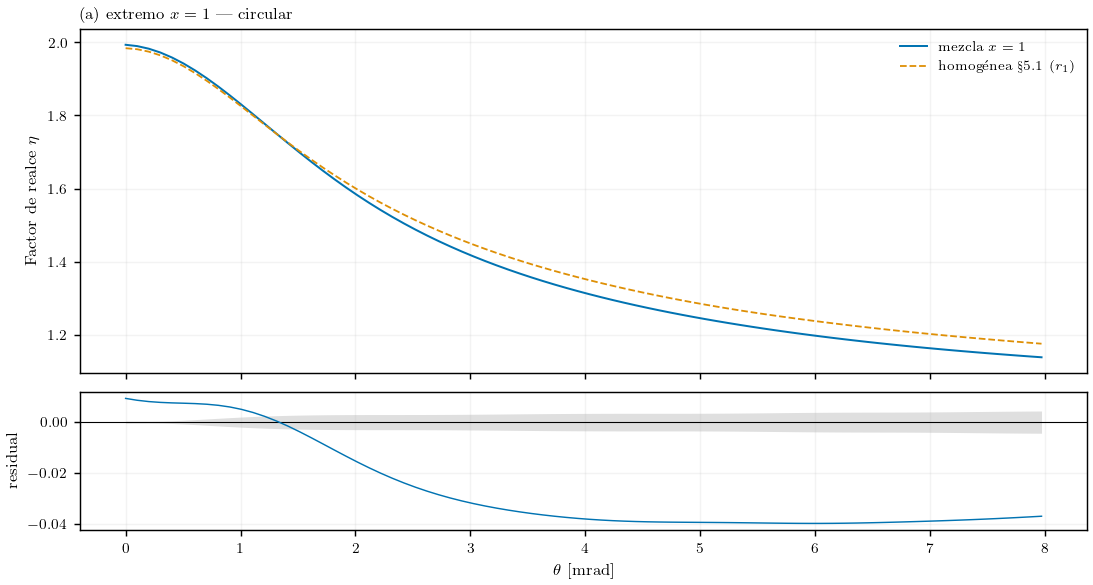

[gate linear x=0] chi2/bin = 14032.97   RMS = 1.71e-01   (ventana <= 8.0 mrad, n=5 réplicas)
[gate linear x=1] chi2/bin = 1409.67   RMS = 4.28e-02   (ventana <= 8.0 mrad, n=5 réplicas)


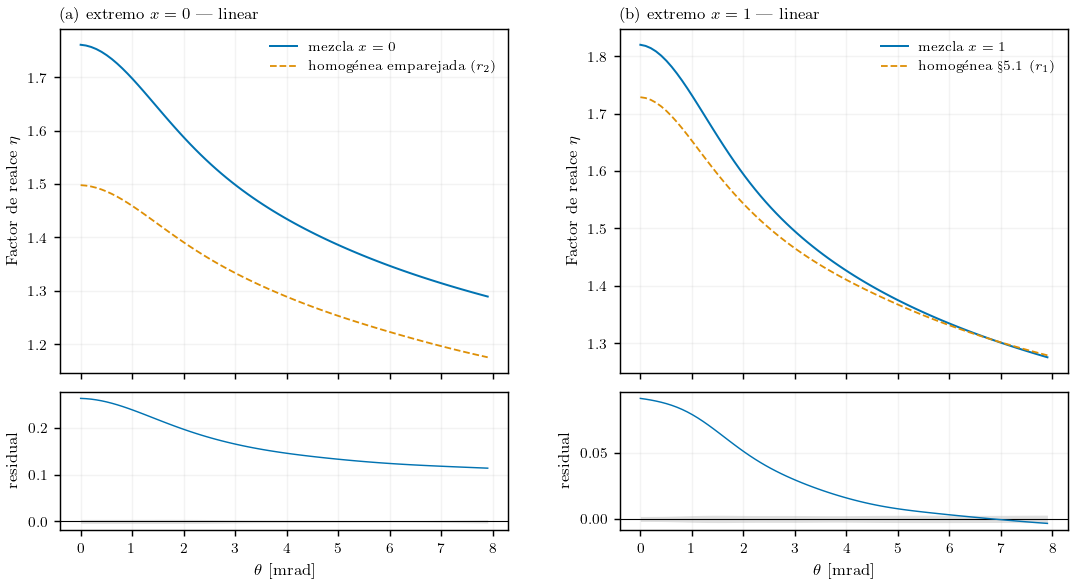


[reciprocidad] E(0) helicidad conservada sobre las 11 composiciones: 1.9896 ± 0.0002   residual máx |E0-2| = 1.06e-02


In [ ]:
replicas_keys_ref_035 = [key for key in data_keys if f"matched_ref_r0.035" in key]
grouped_ref_035 = Grouped(fraction=frac, replicas_keys=replicas_keys_ref_035, name=rf"R={35} nm")

replicas_keys_035 = [key for key in data_keys if f"fraction_0.00" in key]
grouped_035 = Grouped(fraction=0.00, replicas_keys=replicas_keys_035, name=rf"F={0.00:.2f}")

replicas_keys_075 = [key for key in data_keys if f"fraction_1.00" in key]
grouped_075 = Grouped(fraction=1.00, replicas_keys=replicas_keys_075, name=rf"F={1.00:.2f}")







## F10 — Familia de perfiles y colapso de escala

Panel principal: $\gamma(\theta;x)$ en ángulo físico (el ancho varía con $x$). Inset: mismos perfiles contra $q = k\ell^*(x)\theta$ con el $\ell^*$ **propio** de cada composición — si el medio efectivo es exacto, las curvas colapsan en una sola línea universal (en lineal-co colapsa la forma; los ápices quedan separados por la dilución $\rho(x)$).


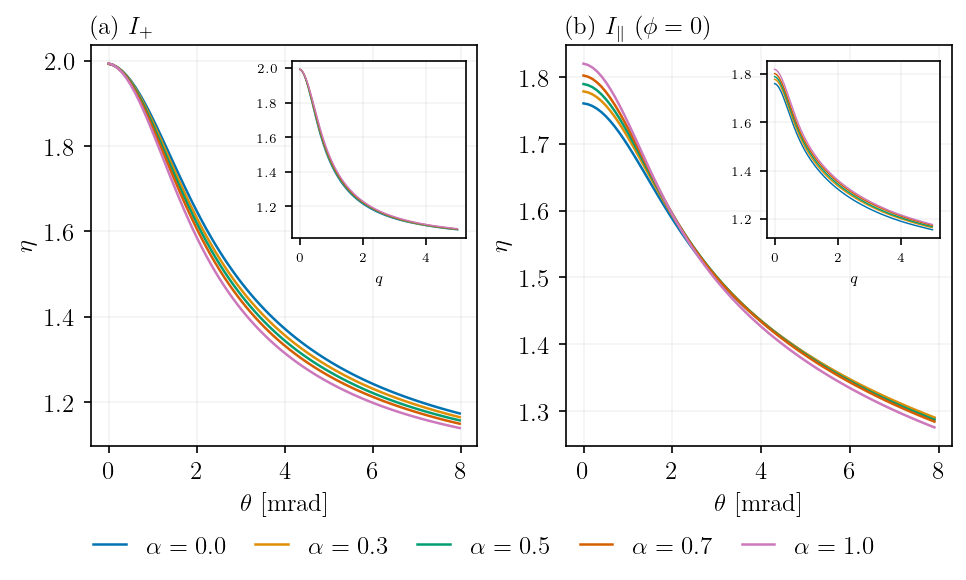

In [38]:
# ===========================================================================
# F10 -- familia gamma(theta; x) + inset de colapso q = k l*(x) theta
# ===========================================================================
F10_X = [0.0, 0.3, 0.5, 0.7, 1.0]
THETA_PLOT_MAX = 8.0     # mrad
Q_INSET_MAX = 5.0

apply(width_frac=1.0)
fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.6 * TEXTWIDTH_IN))
for ax, b, ttl in ((axes[0], "circular", r"(a) $I_+$"),
                   (axes[1], "linear",  r"(b) $I_\parallel$ ($\phi=0$)")):
    ch, bs = CHANNELS[b]["main"], BASIS[b]
    axin = ax.inset_axes([0.52, 0.52, 0.45, 0.44])
    for c, x in zip(COL, F10_X):
        i = int(round(x * (len(fraction_list) - 1)))
        g_ = GROUPS[b][i]
        th, q, Em, Sm = profile_stats_theta(SWEEPS[b], g_, PHI_MAIN, ch, basis=bs)
        se = Sm / np.sqrt(len(g_.replicas_keys))
        thm = th * 1e3
        m = thm <= THETA_PLOT_MAX
        ax.plot(thm[m], Em[m], color=c, label=rf"$\alpha={x:.1f}$")
        ax.fill_between(thm[m], (Em - se)[m], (Em + se)[m], color=c, alpha=0.18, lw=0)
        mi = q <= Q_INSET_MAX
        axin.plot(q[mi], Em[mi], color=c, lw=0.7)
    ax.set_xlabel(r"$\theta$ [mrad]")
    ax.set_ylabel(r"$\eta$")
    ax.grid(alpha=0.15)
    ax.set_title(ttl, loc="left")
    axin.set_xlabel(r"$q$", fontsize=7)
    axin.tick_params(labelsize=6)
    axin.grid(alpha=0.15)

fig.legend(*axes[0].get_legend_handles_labels(),
           ncol=6, loc="outside lower center",
           frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "F10_perfil_familia.pdf")
plt.show()


## F11 — Observables vs composición

Panel (a): $\theta_{\rm FWHM}(x)$ por canal, contra dos predicciones del medio efectivo: la **forma** $\propto 1/\ell^*(x)$ anclada en $x=1$ (punteada) y el estimado absoluto de onda plana $0.73/(k\ell^*(x))$ (discontinua; con el haz de 2500 μm, $w/\ell^*\sim10^2$, debería ser cercano). Panel (b): $E(0)(x)$ por canal; sobre lineal-co, la predicción **aditiva sin parámetros libres** construida desde los extremos [Eq. (mix-rho-linear)].


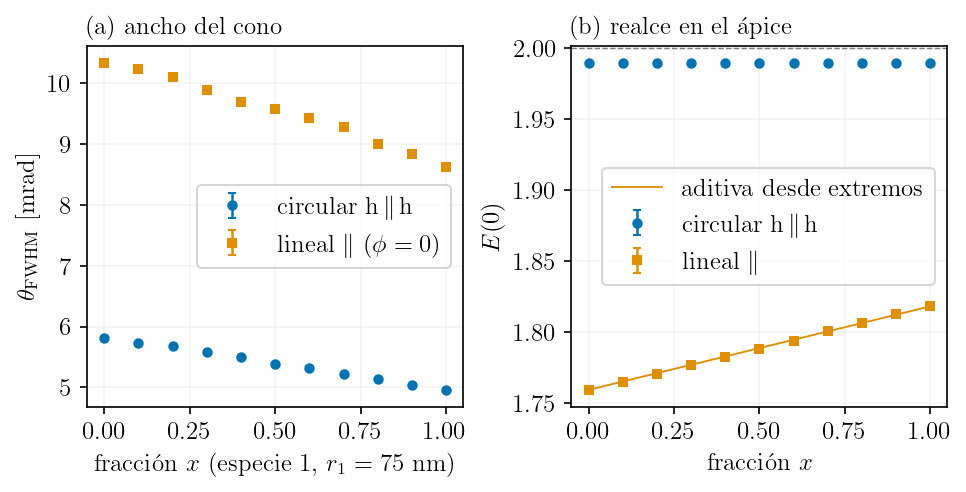

ratio de anchos extremos (circ): FWHM(0)/FWHM(1) = 1.173   predicción l*(1)/l*(0) = 1.266
rho(0) = 0.2407 ± 0.0005    rho(1) = 0.1818 ± 0.0003
rho(0.5) medido = 0.2120 ± 0.0009   promedio de extremos = 0.2112   delta = +7.3e-04


In [26]:
# ===========================================================================
# F11 -- observables vs composición + predicciones de medio efectivo
# ===========================================================================
obs = {}
for b in ("circular", "linear"):
    bs = BASIS[b]
    rows_m, rows_a = [], []
    for i, g_ in enumerate(GROUPS[b]):
        rows_m.append(metric_over_replicas(SWEEPS[b], g_, PHI_MAIN,
                                           CHANNELS[b]["main"], bs, LSTAR[b][i]))
        rows_a.append(metric_over_replicas(SWEEPS[b], g_, PHI_MAIN,
                                           CHANNELS[b]["aux"], bs, LSTAR[b][i]))
    obs[b] = {"main": np.array(rows_m), "aux": np.array(rows_a)}  # cols: E0,sE0,fw,sfw

xv = np.asarray(fraction_list)

apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.5 * TEXTWIDTH_IN))

# --- (a) ancho del cono ---
for b, c, mk, lb in (("circular", COL[0], "o", r"circular h$\,\parallel\,$h"),
                     ("linear",   COL[1], "s", r"lineal $\parallel$ ($\phi=0$)")):
    E0, sE0, fw, sfw = obs[b]["main"].T
    ls_ = LSTAR[b]
    ax1.errorbar(xv, fw, sfw, fmt=mk, ms=4, capsize=2, color=c, ls="none", label=lb)
    # ax1.plot(xv, fw[-1] * ls_[-1] / ls_, ":", color=c, lw=1.0)
    # ax1.plot(xv, 0.73 / (k * ls_) * 1e3, "--", color=c, lw=0.8)
# ax1.plot([], [], ":", c="gray", label="medio efectivo (anclado en $x=1$)")
# ax1.plot([], [], "--", c="gray", label=r"$0.73/(k\ell^*(x))$ (absoluto)")
ax1.set_xlabel(r"fracción $x$ (especie 1, $r_1 = 75$ nm)")
ax1.set_ylabel(r"$\theta_{\rm FWHM}$ [mrad]")
ax1.grid(alpha=0.15); ax1.legend()
ax1.set_title("(a) ancho del cono", loc="left")

for b in obs:   # gate de monotonía
    d = np.diff(obs[b]["main"][:, 2])
    if not (np.all(d <= 0) or np.all(d >= 0)):
        print(f"[WARN] theta_FWHM(x) no monótono en {b}: revisa extracción/ruido")

# --- (b) realce en el ápice ---
for b, c, mk, lb in (("circular", COL[0], "o", r"circular h$\,\parallel\,$h"),
                     ("linear",   COL[1], "s", r"lineal $\parallel$")):
    E0, sE0, _, _ = obs[b]["main"].T
    ax2.errorbar(xv, E0, sE0, fmt=mk, ms=4, capsize=2, color=c, ls="none", label=lb)
E0l = obs["linear"]["main"][:, 0]
ax2.plot(xv, xv * E0l[-1] + (1 - xv) * E0l[0], "-", color=COL[1], lw=0.9, label="aditiva desde extremos")
ax2.axhline(2.0, ls="--", c="gray", lw=0.7)
ax2.set_xlabel(r"fracción $x$")
ax2.set_ylabel(r"$E(0)$")
ax2.grid(alpha=0.15); ax2.legend()
ax2.set_title("(b) realce en el ápice", loc="left")

fig.savefig(FIGDIR / "F11_observables_vs_x.pdf")
plt.show()

# --- números citables ---
rho, srho = 2.0 - obs["linear"]["main"][:, 0], obs["linear"]["main"][:, 1]
fwc = obs["circular"]["main"][:, 2]
print(f"ratio de anchos extremos (circ): FWHM(0)/FWHM(1) = {fwc[0]/fwc[-1]:.3f}   "
      f"predicción l*(1)/l*(0) = {LSTAR['circular'][-1]/LSTAR['circular'][0]:.3f}")
print(f"rho(0) = {rho[0]:.4f} ± {srho[0]:.4f}    rho(1) = {rho[-1]:.4f} ± {srho[-1]:.4f}")
print(f"rho(0.5) medido = {rho[5]:.4f} ± {srho[5]:.4f}   "
      f"promedio de extremos = {0.5*(rho[0]+rho[-1]):.4f}   "
      f"delta = {rho[5]-0.5*(rho[0]+rho[-1]):+.1e}")


## F12 — Test de superposición en $x=0.5$

La superposición naive se construye al nivel de **intensidades** [Eq. (mix-naive)]:
$\gamma_{\rm naive} = \dfrac{x\,I_1 + (1-x)\,I_2}{x\,B_1 + (1-x)\,B_2}$,
con $I$ = intensidad total y $B$ = fondo incoherente de los extremos, **pareando réplica a réplica** (residual con error estándar honesto sobre las $n$ réplicas). El residual esperado es la brecha de Jensen [Eq. (mix-jensen)]: alternante en signo, extremal a medio cono.


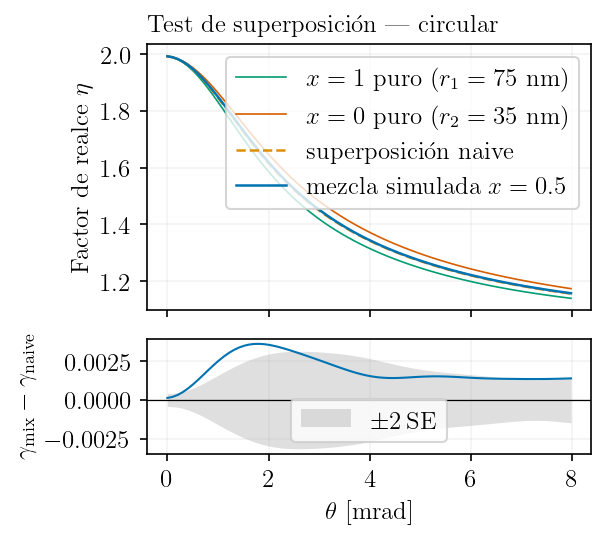

[F12 circular] FWHM_q sim = 1.796   naive = 1.784   (delta = -0.7 %)
[F12 circular] E0 sim = 1.9896   naive = 1.9894   chi2/bin(residual) = 4.10
[F12 circular] cruces por cero del residual: [] mrad


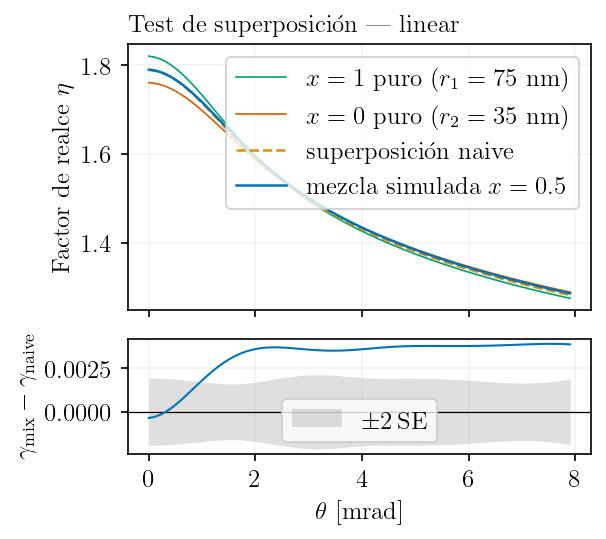

[F12 linear] FWHM_q sim = 3.193   naive = 3.137   (delta = -1.8 %)
[F12 linear] E0 sim = 1.7880   naive = 1.7883   chi2/bin(residual) = 14.31
[F12 linear] cruces por cero del residual: [] mrad


In [27]:
# ===========================================================================
# F12 -- superposición naive vs mezcla simulada en x = 0.5
# ===========================================================================
X_TEST = 0.5
I_TEST = int(round(X_TEST * (len(fraction_list) - 1)))
THETA_PLOT_MAX = 8.0

for b in ("circular", "linear"):
    ch, bs = CHANNELS[b]["main"], BASIS[b]
    pr = paired_residual(b, I_TEST)
    thm = pr["theta"] * 1e3
    m = thm <= THETA_PLOT_MAX

    _, _, E0m, _ = profile_stats_theta(SWEEPS[b], GROUPS[b][0],  PHI_MAIN, ch, basis=bs)
    _, _, E1m, _ = profile_stats_theta(SWEEPS[b], GROUPS[b][-1], PHI_MAIN, ch, basis=bs)
    
    apply(width_frac=0.62)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(0.62 * TEXTWIDTH_IN, 0.55 * TEXTWIDTH_IN),
                                   sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1.3],
                                                "hspace": 0.08})
    ax1.plot(thm[m], E1m[m], color=COL[2], lw=0.8, label=r"$x=1$ puro ($r_1=75$ nm)")
    ax1.plot(thm[m], E0m[m], color=COL[3], lw=0.8, label=r"$x=0$ puro ($r_2=35$ nm)")
    ax1.plot(thm[m], pr["naive_mean"][m], "--", color=COL[1], lw=1.2,
             label=r"superposición naive")
    ax1.plot(thm[m], pr["sim_mean"][m], color=COL[0], lw=1.2,
             label=r"mezcla simulada $x=0.5$")
    ax1.set_ylabel(r"Factor de realce $\eta$")
    ax1.grid(alpha=0.15); ax1.legend()
    ax1.set_title(f"Test de superposición — {b}", loc="left")

    band = 2 * pr["res_se"]
    ax2.axhline(0, c="k", lw=0.6)
    ax2.fill_between(thm[m], -band[m], band[m], color="gray", alpha=0.25, lw=0,
                     label=r"$\pm2\,$SE")
    ax2.plot(thm[m], pr["res_mean"][m], color=COL[0], lw=1.0)
    ax2.set_xlabel(r"$\theta$ [mrad]")
    ax2.set_ylabel(r"$\gamma_{\rm mix}-\gamma_{\rm naive}$")
    ax2.grid(alpha=0.15); ax2.legend()
    fig.savefig(FIGDIR / f"F12_superposicion_{b}.pdf")
    plt.show()

    # --- números citables: FWHM, chi2, cruces por cero ---
    q_test = k * LSTAR[b][I_TEST] * pr["theta"]
    e0_s, fw_s = peak_height(q_test, pr["sim_mean"]), fwhm_q(q_test, pr["sim_mean"])
    e0_n, fw_n = peak_height(q_test, pr["naive_mean"]), fwhm_q(q_test, pr["naive_mean"])
    mw = m & (thm > 0.3)
    chi2 = np.mean((pr["res_mean"][mw]
                    / np.where(pr["res_se"][mw] > 0, pr["res_se"][mw], np.inf)) ** 2)
    # cruces por cero sobre el residual suavizado (solo para localizarlos)
    kern = np.ones(7) / 7.0
    rs = np.convolve(pr["res_mean"], kern, mode="same")[mw]
    th_w = thm[mw]
    cross = th_w[1:][np.diff(np.sign(rs)) != 0]
    print(f"[F12 {b}] FWHM_q sim = {fw_s:.3f}   naive = {fw_n:.3f}   "
          f"(delta = {100*(fw_n/fw_s - 1):+.1f} %)")
    print(f"[F12 {b}] E0 sim = {e0_s:.4f}   naive = {e0_n:.4f}   "
          f"chi2/bin(residual) = {chi2:.2f}")
    print(f"[F12 {b}] cruces por cero del residual: {np.round(cross[:4], 2)} mrad")


## F12b — Escalado $x(1-x)$ del residual

Predicción (ii) de la expansión de Jensen: la amplitud del residual es $\propto x(1-x)$. Para cada composición interior se calcula el RMS del residual medio en una ventana angular fija; el **piso de ruido** (RMS esperado si el residual fuera cero, estimado del SE por réplicas) se resta en cuadratura. Ajuste: recta por el origen ponderada.


[circular] x=0.1   RMS=1.68e-03   piso=1.03e-03   señal=1.34e-03
[circular] x=0.2   RMS=2.34e-03   piso=6.93e-04   señal=2.23e-03
[circular] x=0.3   RMS=2.73e-03   piso=9.12e-04   señal=2.58e-03
[circular] x=0.4   RMS=2.82e-03   piso=7.92e-04   señal=2.71e-03
[circular] x=0.5   RMS=2.35e-03   piso=1.21e-03   señal=2.01e-03
[circular] x=0.6   RMS=3.02e-03   piso=8.03e-04   señal=2.91e-03
[circular] x=0.7   RMS=1.64e-03   piso=9.49e-04   señal=1.34e-03
[circular] x=0.8   RMS=1.39e-03   piso=7.53e-04   señal=1.17e-03
[circular] x=0.9   RMS=7.60e-04   piso=1.15e-03   señal=0.00e+00
[linear] x=0.1   RMS=1.63e-03   piso=6.58e-04   señal=1.49e-03
[linear] x=0.2   RMS=2.95e-03   piso=9.08e-04   señal=2.80e-03
[linear] x=0.3   RMS=3.00e-03   piso=6.44e-04   señal=2.93e-03
[linear] x=0.4   RMS=2.72e-03   piso=6.78e-04   señal=2.64e-03
[linear] x=0.5   RMS=3.37e-03   piso=9.48e-04   señal=3.23e-03
[linear] x=0.6   RMS=3.10e-03   piso=7.03e-04   señal=3.02e-03
[linear] x=0.7   RMS=3.40e-03   piso=

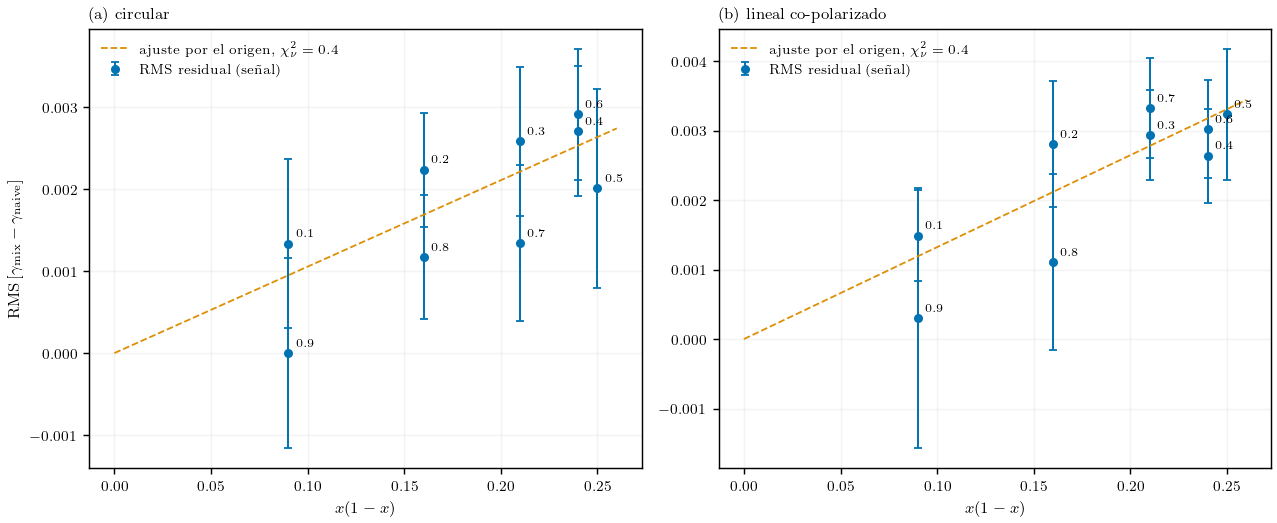

In [14]:
# ===========================================================================
# F12b -- RMS del residual vs x(1-x): la verificación funcional de 2º orden
# ===========================================================================
W_MRAD = (0.4, 6.0)      # ventana angular fija (cono, sin el ápice ruidoso)

fig, axes = plt.subplots(1, 2, figsize=(TEXTW, 0.42 * TEXTW), sharex=True)
for ax, b, ttl in ((axes[0], "circular", "(a) circular"),
                   (axes[1], "linear", "(b) lineal co-polarizado")):
    xs, amp, s_amp = [], [], []
    for i in range(1, len(fraction_list) - 1):
        pr = paired_residual(b, i)
        thm = pr["theta"] * 1e3
        m = (thm >= W_MRAD[0]) & (thm <= W_MRAD[1])
        rms = np.sqrt(np.mean(pr["res_mean"][m] ** 2))
        floor = np.sqrt(np.mean(pr["res_se"][m] ** 2))       # RMS esperado si res = 0
        sig = np.sqrt(max(rms ** 2 - floor ** 2, 0.0))       # señal (piso en cuadratura)
        xs.append(pr["x"]); amp.append(sig); s_amp.append(floor)
        print(f"[{b}] x={pr['x']:.1f}   RMS={rms:.2e}   piso={floor:.2e}   señal={sig:.2e}")
    xs, amp, s_amp = np.asarray(xs), np.asarray(amp), np.asarray(s_amp)
    u = xs * (1 - xs)

    w = 1.0 / np.maximum(s_amp, 1e-12) ** 2                  # recta por el origen
    slope = np.sum(w * u * amp) / np.sum(w * u ** 2)
    resid = amp - slope * u
    chi2fit = np.sum(w * resid ** 2) / max(len(u) - 1, 1)
    uu = np.linspace(0, 0.26, 50)

    ax.errorbar(u, amp, s_amp, fmt="o", ms=4, capsize=2, color=COL[0], ls="none",
                label="RMS residual (señal)")
    ax.plot(uu, slope * uu, "--", color=COL[1], lw=1.0,
            label=rf"ajuste por el origen, $\chi^2_\nu={chi2fit:.1f}$")
    for xi, ui, ai in zip(xs, u, amp):
        ax.annotate(rf"${xi:.1f}$", (ui, ai), textcoords="offset points",
                    xytext=(4, 4), fontsize=6.5)
    ax.set_xlabel(r"$x(1-x)$")
    ax.set_title(ttl, loc="left")
    ax.grid(alpha=0.15); ax.legend()
axes[0].set_ylabel(r"RMS$\,[\gamma_{\rm mix}-\gamma_{\rm naive}]$")
fig.tight_layout()
fig.savefig(FIGDIR / "F12b_escalado_x1mx.pdf")
plt.show()


## Tabla de degeneración

$(x,\ \ell^*,\ \theta_{\rm FWHM},\ E_0^{\rm circ},\ E_0^{\rm lin,co},\ \rho)$ con errores estándar sobre réplicas. Exporta CSV (datos) y filas LaTeX listas para `tab:mix-degeneracy`. El punto de la sección: el ancho mide solo $\ell^*(x)$ (degenerado con un monodisperso equivalente); $\rho(x)$ discrimina composición.


In [15]:
# ===========================================================================
# Tabla de degeneración -> CSV + filas LaTeX
#   Requiere haber corrido F11 (usa `obs`).
# ===========================================================================
rows = []
for i, x in enumerate(fraction_list):
    E0c, sE0c, fwc, sfwc = obs["circular"]["main"][i]
    E0l, sE0l, fwl, sfwl = obs["linear"]["main"][i]
    rows.append({
        "x": x, "lstar_um": LSTAR["circular"][i],
        "FWHM_circ_mrad": fwc, "s_FWHM_circ": sfwc,
        "FWHM_lin_mrad": fwl, "s_FWHM_lin": sfwl,
        "E0_circ": E0c, "s_E0_circ": sE0c,
        "E0_lin_co": E0l, "s_E0_lin": sE0l,
        "rho": 2.0 - E0l, "s_rho": sE0l,
    })
df_deg = pd.DataFrame(rows)
df_deg.to_csv(FIGDIR / "tabla_degeneracion.csv", index=False)
display(df_deg.round(4))

def pm(v, s, nd=3):
    return rf"${v:.{nd}f} \pm {s:.{nd}f}$"

lines = []
for _, r in df_deg.iterrows():
    lines.append("    " + " & ".join([
        f"{r['x']:.1f}",
        f"{r['lstar_um']:.2f}",
        pm(r["FWHM_circ_mrad"], r["s_FWHM_circ"], 2),
        pm(r["E0_circ"], r["s_E0_circ"]),
        pm(r["E0_lin_co"], r["s_E0_lin"]),
        pm(r["rho"], r["s_rho"]),
    ]) + r" \\")
tex = "\n".join(lines)
(FIGDIR / "tabla_degeneracion.tex").write_text(tex)
print(tex)

span_fw = 100 * (df_deg["FWHM_circ_mrad"].iloc[0] / df_deg["FWHM_circ_mrad"].iloc[-1] - 1)
span_rho = 100 * (df_deg["rho"].iloc[0] / df_deg["rho"].iloc[-1] - 1)
print(f"\ncontraste a través del barrido:  FWHM_circ {span_fw:.0f} %    rho {span_rho:.0f} %")
print(f"guardado: {FIGDIR/'tabla_degeneracion.csv'} y {FIGDIR/'tabla_degeneracion.tex'}")


,x,lstar_um,FWHM_circ_mrad,s_FWHM_circ,FWHM_lin_mrad,s_FWHM_lin,E0_circ,s_E0_circ,E0_lin_co,s_E0_lin,rho,s_rho
0,0.0,18.2956,5.8162,0.0115,10.3274,0.0176,1.9894,0.0002,1.7593,0.0005,0.2407,0.0005
1,0.1,18.7145,5.7235,0.0120,10.2290,0.0213,1.9900,0.0001,1.7649,0.0004,0.2351,0.0004
2,0.2,19.0641,5.6759,0.0104,10.1115,0.0306,1.9895,0.0001,1.7708,0.0003,0.2292,0.0003
3,0.3,19.5195,5.5742,0.0127,9.8849,0.0223,1.9898,0.0002,1.7771,0.0004,0.2229,0.0004
4,0.4,19.9658,5.4913,0.0082,9.6967,0.0266,1.9896,0.0002,1.7825,0.0005,0.2175,0.0005
5,0.5,20.4840,5.3845,0.0144,9.5739,0.0168,1.9896,0.0003,1.7880,0.0009,0.2120,0.0009
6,0.6,20.9601,5.3185,0.0078,9.4374,0.0293,1.9894,0.0002,1.7940,0.0005,0.2060,0.0005
7,0.7,21.4741,5.2208,0.0038,9.2739,0.0352,1.9894,0.0003,1.8007,0.0003,0.1993,0.0003
8,0.8,21.9889,5.1407,0.0077,9.0032,0.0098,1.9897,0.0002,1.8064,0.0006,0.1936,0.0006
9,0.9,22.5503,5.0434,0.0139,8.8414,0.0542,1.9896,0.0003,1.8129,0.0006,0.1871,0.0006


    0.0 & 18.30 & $5.82 \pm 0.01$ & $1.989 \pm 0.000$ & $1.759 \pm 0.001$ & $0.241 \pm 0.001$ \\
    0.1 & 18.71 & $5.72 \pm 0.01$ & $1.990 \pm 0.000$ & $1.765 \pm 0.000$ & $0.235 \pm 0.000$ \\
    0.2 & 19.06 & $5.68 \pm 0.01$ & $1.989 \pm 0.000$ & $1.771 \pm 0.000$ & $0.229 \pm 0.000$ \\
    0.3 & 19.52 & $5.57 \pm 0.01$ & $1.990 \pm 0.000$ & $1.777 \pm 0.000$ & $0.223 \pm 0.000$ \\
    0.4 & 19.97 & $5.49 \pm 0.01$ & $1.990 \pm 0.000$ & $1.782 \pm 0.001$ & $0.218 \pm 0.001$ \\
    0.5 & 20.48 & $5.38 \pm 0.01$ & $1.990 \pm 0.000$ & $1.788 \pm 0.001$ & $0.212 \pm 0.001$ \\
    0.6 & 20.96 & $5.32 \pm 0.01$ & $1.989 \pm 0.000$ & $1.794 \pm 0.000$ & $0.206 \pm 0.000$ \\
    0.7 & 21.47 & $5.22 \pm 0.00$ & $1.989 \pm 0.000$ & $1.801 \pm 0.000$ & $0.199 \pm 0.000$ \\
    0.8 & 21.99 & $5.14 \pm 0.01$ & $1.990 \pm 0.000$ & $1.806 \pm 0.001$ & $0.194 \pm 0.001$ \\
    0.9 & 22.55 & $5.04 \pm 0.01$ & $1.990 \pm 0.000$ & $1.813 \pm 0.001$ & $0.187 \pm 0.001$ \\
    1.0 & 23.16 & $4.96 \pm 0.